📊 Realized Increment Strategy (RI) — Out-of-Sample, Spread 1
Rolling Window       : 46
Alpha Quantiles      : 0.030, 0.970
Sharpe Ratio         : 1.3743
Total Return         : 13692.8855
Max Drawdown         : 1719.5036
Win Rate             : 34.01%


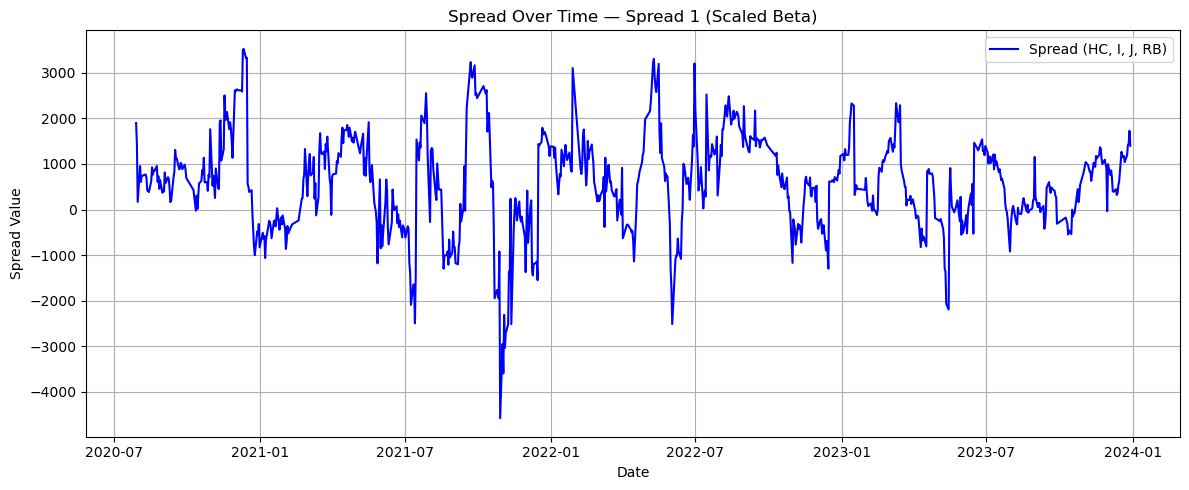

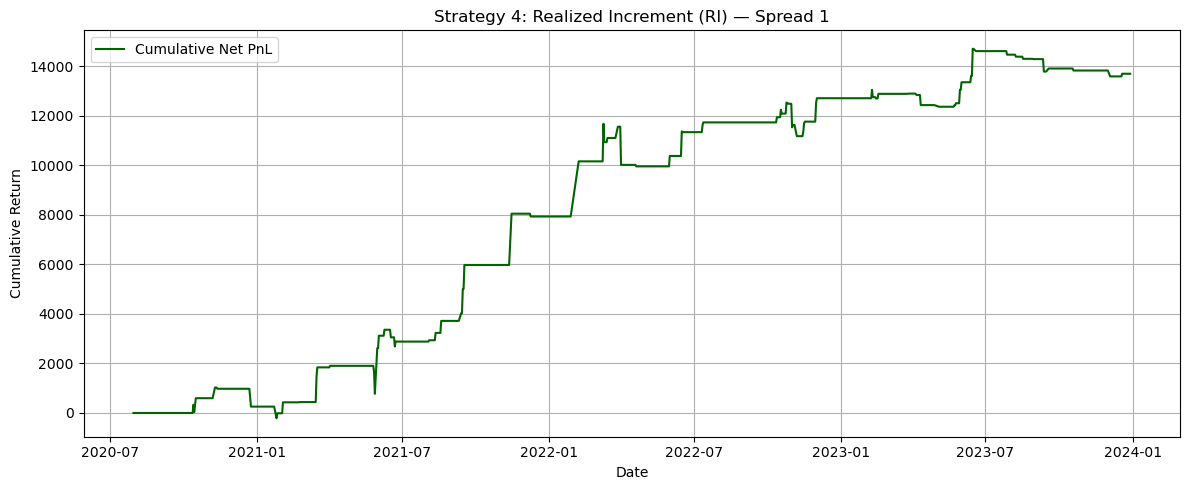

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === Step 0: Load Data ===
df = pd.read_excel("futures_clean.csv.xlsx", index_col=0, parse_dates=True)
df_coint = df[['RB', 'J', 'I', 'HC']].dropna()
df_oos = df_coint.iloc[:833]

# === Step 1: Construct Spread with Scaled Beta ===
beta_1_scaled = np.array([6.5748, -1.566, -0.6142, -5.0005])
spread = df_oos.values @ beta_1_scaled
spread = pd.Series(spread, index=df_oos.index)

# === Step 2: Compute Spread Increment ===
increment = spread.pct_change().fillna(0)

# === Step 3: Strategy Parameters ===
window = 46
alpha = 0.03
cost = 0.0005

# === Step 4: Initialize Position ===
position = np.zeros(len(spread))
q_low = np.full(len(spread), np.nan)
q_high = np.full(len(spread), np.nan)

# === Step 5: Rolling Quantiles and Position Logic ===
for i in range(window, len(spread)):
    window_increments = increment.iloc[i - window:i]
    q_alpha = np.quantile(window_increments, alpha)
    q_1_alpha = np.quantile(window_increments, 1 - alpha)
    q_low[i] = q_alpha
    q_high[i] = q_1_alpha

    # No open position
    if position[i - 1] == 0:
        if increment.iloc[i] < q_alpha:
            position[i] = 1   # Long
        elif increment.iloc[i] > q_1_alpha:
            position[i] = -1  # Short
        else:
            position[i] = 0
    else:
        # Exit if increment crosses back inside the band
        if q_alpha <= increment.iloc[i] <= q_1_alpha:
            position[i] = 0
        else:
            position[i] = position[i - 1]  # Hold

position = pd.Series(position, index=spread.index)

# === Step 6: Compute Returns ===
spread_return = spread.diff().fillna(0)
turnover = position.diff().abs()
strategy_returns = position.shift(1) * spread_return
costs = turnover * cost
net_returns = strategy_returns - costs
cumulative_pnl = net_returns.cumsum()

# === Step 7: Metrics ===
sharpe = net_returns.mean() / net_returns.std() * np.sqrt(252) if net_returns.std() > 0 else 0
max_dd = (cumulative_pnl.cummax() - cumulative_pnl).max()
win_rate = (net_returns > 0).sum() / (net_returns != 0).sum()
total_return = cumulative_pnl.iloc[-1]

# === Step 8: Print Summary ===
print("📊 Realized Increment Strategy (RI) — Out-of-Sample, Spread 1")
print(f"Rolling Window       : {window}")
print(f"Alpha Quantiles      : {alpha:.3f}, {1-alpha:.3f}")
print(f"Sharpe Ratio         : {sharpe:.4f}")
print(f"Total Return         : {total_return:.4f}")
print(f"Max Drawdown         : {max_dd:.4f}")
print(f"Win Rate             : {win_rate:.2%}")

# === Step 9: Plot Spread ===
plt.figure(figsize=(12, 5))
plt.plot(spread, label="Spread (HC, I, J, RB)", color="blue")
plt.title("Spread Over Time — Spread 1 (Scaled Beta)")
plt.xlabel("Date")
plt.ylabel("Spread Value")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# === Step 10: Plot Strategy Cumulative PnL ===
plt.figure(figsize=(12, 5))
plt.plot(cumulative_pnl, label="Cumulative Net PnL", color="darkgreen")
plt.title("Strategy 4: Realized Increment (RI) — Spread 1")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# === Load and compute spread ===
df = pd.read_excel("futures_clean.csv.xlsx", index_col=0, parse_dates=True)
df_coint = df[['HC', 'I', 'J', 'RB']].dropna()
df_oos = df_coint.iloc[:833]
beta_1_scaled = np.array([5.00051, 0.6142, 1.56603, -6.57481])
spread = df_oos.values @ beta_1_scaled
spread = pd.Series(spread, index=df_oos.index)
increment = spread.pct_change().fillna(0)

# === Strategy Function ===
def run_RI_strategy(spread, increment, window, alpha, cost=0.5):
    position = np.zeros(len(spread))
    for i in range(window, len(spread)):
        window_increments = increment.iloc[i - window:i]
        q_alpha = np.quantile(window_increments, alpha)
        q_1_alpha = np.quantile(window_increments, 1 - alpha)

        if position[i - 1] == 0:
            if increment.iloc[i] < q_alpha:
                position[i] = 1
            elif increment.iloc[i] > q_1_alpha:
                position[i] = -1
            else:
                position[i] = 0
        else:
            if q_alpha <= increment.iloc[i] <= q_1_alpha:
                position[i] = 0
            else:
                position[i] = position[i - 1]

    position = pd.Series(position, index=spread.index)
    spread_return = spread.diff().fillna(0)
    turnover = position.diff().abs()
    strategy_returns = position.shift(1) * spread_return
    cost_penalty = turnover * cost
    net_returns = strategy_returns - cost_penalty

    if net_returns.std() == 0:
        return -np.inf
    return net_returns.mean() / net_returns.std() * np.sqrt(252)

# === Grid Search ===
window_list = range(10, 201, 1)
alpha_list = np.round(np.arange(0.01, 0.051, 0.01), 3)
results = pd.DataFrame(index=alpha_list, columns=window_list)

for alpha in alpha_list:
    for window in window_list:
        sharpe = run_RI_strategy(spread, increment, window, alpha)
        results.loc[alpha, window] = sharpe

# === Find Best ===
best_alpha, best_window = results.stack().astype(float).idxmax()
best_sharpe = results.stack().astype(float).max()

print("✅ Best Parameters for RI Strategy")
print(f"Best Window Length : {best_window}")
print(f"Best Alpha          : {best_alpha}")
print(f"Best Sharpe Ratio   : {best_sharpe:.4f}")

# === Plot Heatmap ===
plt.figure(figsize=(12, 6))
sns.heatmap(results.astype(float), annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Sharpe Ratio Heatmap — RI Strategy (Out-of-Sample, Spread 1)")
plt.xlabel("Rolling Window")
plt.ylabel("Alpha (Quantile Level)")
plt.tight_layout()
plt.show()


📊 Realized Increment Strategy (RI) — Out-of-Sample, Spread 1
Rolling Window       : 46
Alpha Quantiles      : 0.030, 0.970
Sharpe Ratio         : -1.1529
Total Return         : -3155.9500
Max Drawdown         : 4065.3008
Win Rate             : 23.21%


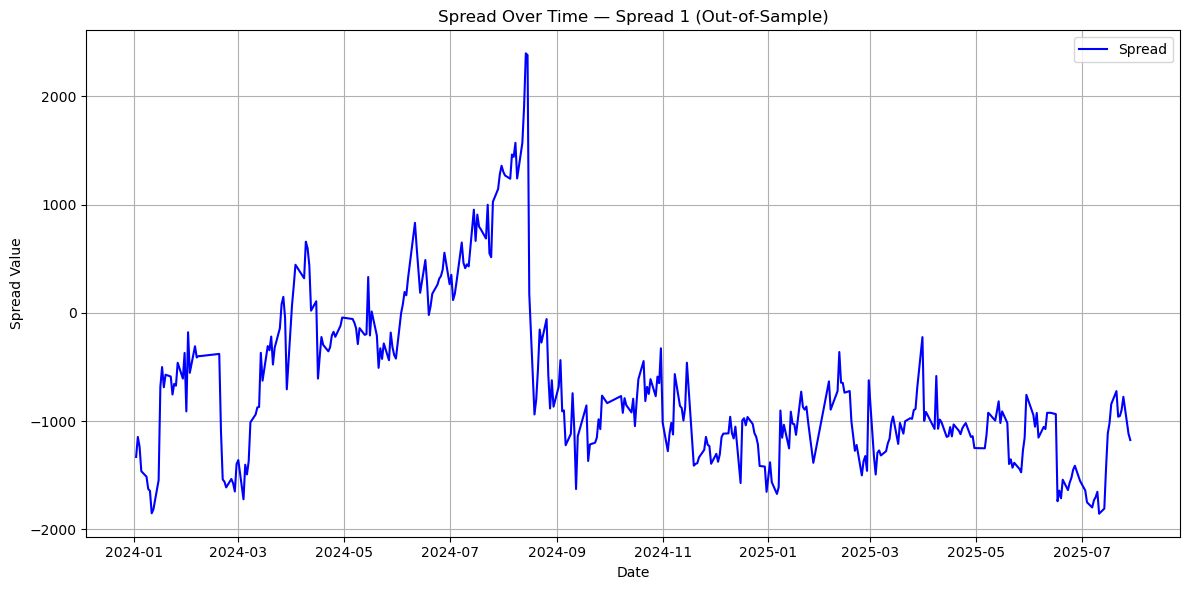

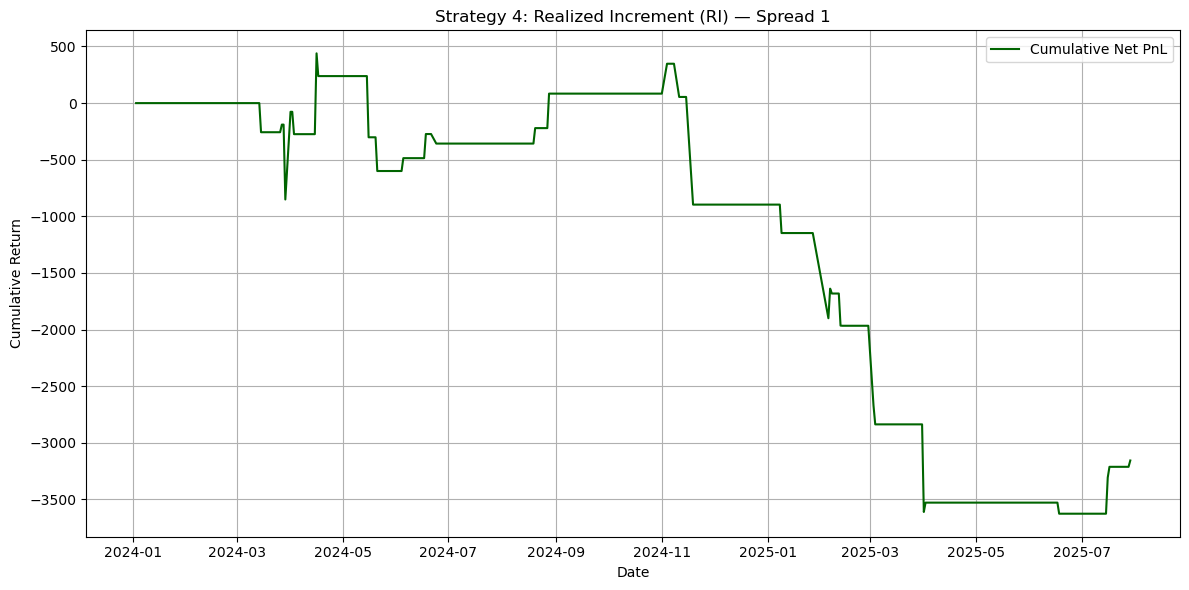

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === Step 0: Load Data ===
df = pd.read_excel("futures_clean.csv.xlsx", index_col=0, parse_dates=True)
df_coint = df[['HC', 'I', 'J', 'RB']].dropna()
df_oos = df_coint.iloc[833:]

# === Step 1: Construct Spread with Scaled Beta ===
beta_1_scaled = np.array([5.00051, 0.6142, 1.56603, -6.57481])
spread = df_oos.values @ beta_1_scaled
spread = pd.Series(spread, index=df_oos.index)

# === Step 2: Compute Spread Increment ===
increment = spread.pct_change().fillna(0)

# === Step 3: Strategy Parameters ===
window = 46
alpha = 0.03
cost = 0.0005

# === Step 4: Initialize Position ===
position = np.zeros(len(spread))
q_low = np.full(len(spread), np.nan)
q_high = np.full(len(spread), np.nan)

# === Step 5: Rolling Quantiles and Position Logic ===
for i in range(window, len(spread)):
    window_increments = increment.iloc[i - window:i]
    q_alpha = np.quantile(window_increments, alpha)
    q_1_alpha = np.quantile(window_increments, 1 - alpha)
    q_low[i] = q_alpha
    q_high[i] = q_1_alpha

    # No open position
    if position[i - 1] == 0:
        if increment.iloc[i] < q_alpha:
            position[i] = 1   # Long
        elif increment.iloc[i] > q_1_alpha:
            position[i] = -1  # Short
        else:
            position[i] = 0
    else:
        # Exit if increment crosses back inside the band
        if q_alpha <= increment.iloc[i] <= q_1_alpha:
            position[i] = 0
        else:
            position[i] = position[i - 1]  # Hold

position = pd.Series(position, index=spread.index)

# === Step 6: Compute Returns ===
spread_return = spread.diff().fillna(0)
turnover = position.diff().abs()
strategy_returns = position.shift(1) * spread_return
costs = turnover * cost
net_returns = strategy_returns - costs
cumulative_pnl = net_returns.cumsum()

# === Step 7: Metrics ===
sharpe = net_returns.mean() / net_returns.std() * np.sqrt(252) if net_returns.std() > 0 else 0
max_dd = (cumulative_pnl.cummax() - cumulative_pnl).max()
win_rate = (net_returns > 0).sum() / (net_returns != 0).sum()
total_return = cumulative_pnl.iloc[-1]

# === Step 8: Print Results ===
print("📊 Realized Increment Strategy (RI) — Out-of-Sample, Spread 1")
print(f"Rolling Window       : {window}")
print(f"Alpha Quantiles      : {alpha:.3f}, {1-alpha:.3f}")
print(f"Sharpe Ratio         : {sharpe:.4f}")
print(f"Total Return         : {total_return:.4f}")
print(f"Max Drawdown         : {max_dd:.4f}")
print(f"Win Rate             : {win_rate:.2%}")

# === Step 9: Plot Spread ===
plt.figure(figsize=(12, 6))
plt.plot(spread, label="Spread", color="blue")
plt.title("Spread Over Time — Spread 1 (Out-of-Sample)")
plt.xlabel("Date")
plt.ylabel("Spread Value")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# === Step 10: Plot Cumulative PnL ===
plt.figure(figsize=(12, 6))
plt.plot(cumulative_pnl, label="Cumulative Net PnL", color="darkgreen")
plt.title("Strategy 4: Realized Increment (RI) — Spread 1")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


✅ Excel saved: Realized Increment Strategy with Integer Hands.xlsx

📊 Realized Increment Strategy (All Data, Integer Hands)
Initial Capital Deployed: 0.00 RMB
Final Cumulative Profit: -16,612,590.00 RMB
Profit Rate: -inf%
Sharpe Ratio: -1.1336
Max Drawdown: 17,080,280.00
Win Rate: 43.09%


C:\Users\chris\AppData\Local\Temp\ipykernel_53396\2876893371.py:121: RuntimeWarning: divide by zero encountered in scalar divide
  profit_rate = final_profit / initial_capital


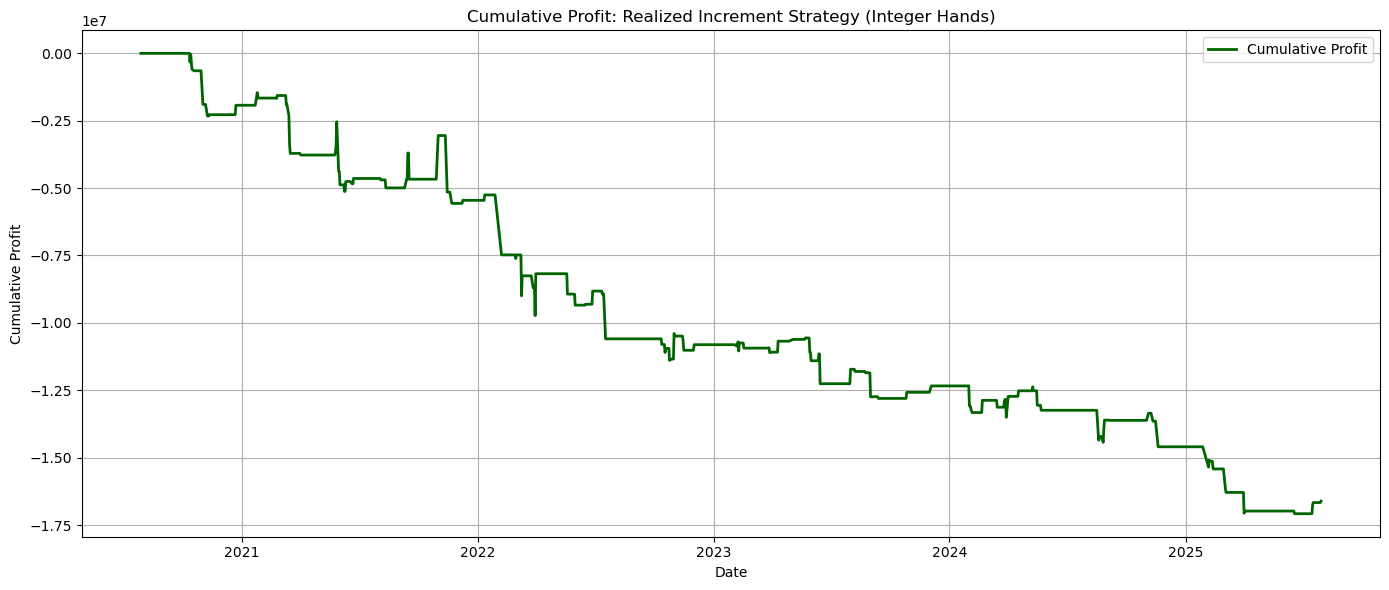

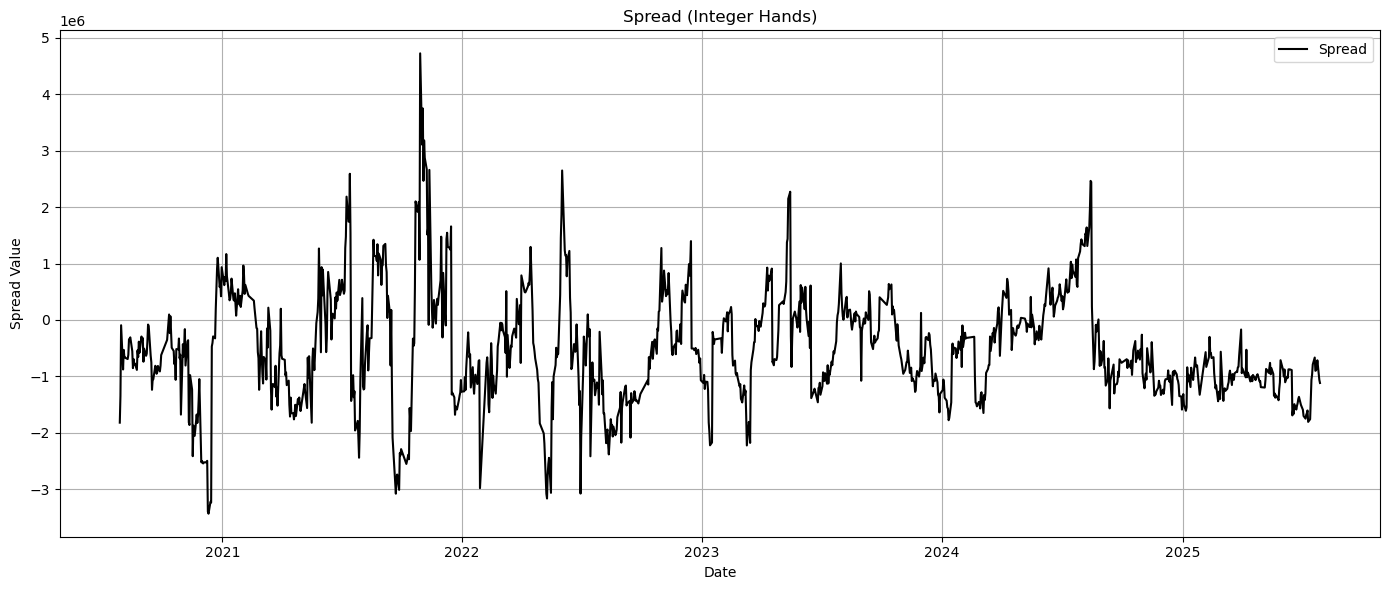

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === Step 0: Load data ===
df = pd.read_excel("futures_clean.csv.xlsx", index_col=0, parse_dates=True)
df_coint = df[['HC', 'I', 'J', 'RB']].dropna()
df_coint_full = df_coint

# === Step 1: Define original beta and contract sizes ===
original_beta = {'HC': 5.00051, 'I': 0.6142, 'J': 1.56603, 'RB': -6.57481}
contract_sizes = {'HC': 10, 'I': 100, 'J': 100, 'RB': 10}
scaling_factor = 1000
scaled_beta = {k: original_beta[k] * scaling_factor for k in original_beta}
scaled_hands = {k: round(scaled_beta[k] / contract_sizes[k]) for k in scaled_beta}

# === Step 2: Integer-based spread computation ===
beta_1 = np.array([
    scaled_hands['HC'] * contract_sizes['HC'],
    scaled_hands['I']  * contract_sizes['I'],
    scaled_hands['J']  * contract_sizes['J'],
    scaled_hands['RB'] * contract_sizes['RB']
])
spread = df_coint_full.values @ beta_1
spread = pd.Series(spread, index=df_coint_full.index)

# === Step 3: Realized increment strategy parameters ===
increment = spread.pct_change().fillna(0)
window = 46
alpha = 0.03
transaction_cost = 0.0000

# === Step 4: Initialize strategy variables ===
position = np.zeros(len(spread))
q_low = np.full(len(spread), np.nan)
q_high = np.full(len(spread), np.nan)

# === Step 5: Generate signals using rolling quantiles ===
for i in range(window, len(spread)):
    window_increments = increment.iloc[i - window:i]
    q_alpha = np.quantile(window_increments, alpha)
    q_1_alpha = np.quantile(window_increments, 1 - alpha)
    q_low[i] = q_alpha
    q_high[i] = q_1_alpha

    if position[i - 1] == 0:
        if increment.iloc[i] < q_alpha:
            position[i] = 1
        elif increment.iloc[i] > q_1_alpha:
            position[i] = -1
    else:
        if q_alpha <= increment.iloc[i] <= q_1_alpha:
            position[i] = 0
        else:
            position[i] = position[i - 1]

position = pd.Series(position, index=spread.index)

# === Step 6: PnL and exposure tracking ===
daily_profit = [0]
cumulative_profit = [0]
gross_exposure = []
net_exposure = []
position_type = []
position_details = []

first_day_details = {k: 0 for k in ['HC', 'I', 'J', 'RB']}
position_details.append(first_day_details)
gross_exposure.append(0)
net_exposure.append(0)
position_type.append("None")

for i in range(1, len(df_coint_full)):
    prices = df_coint_full.iloc[i]
    pos_yesterday = position.iloc[i - 1]
    pos_today = position.iloc[i]

    # Exposure
    value_dict = {}
    for k in ['HC', 'I', 'J', 'RB']:
        hands = scaled_hands[k]
        size = contract_sizes[k]
        price = prices[k]
        notional = pos_today * hands * size * price
        value_dict[k] = notional
    total_gross = sum(abs(v) for v in value_dict.values())
    total_net = abs(sum(value_dict.values()))

    # Spread PnL
    spread_change = spread.iloc[i] - spread.iloc[i - 1]
    profit = spread_change * pos_yesterday

    # Transaction cost if position changed
    if pos_today != pos_yesterday:
        profit -= transaction_cost * total_gross

    daily_profit.append(profit)
    cumulative_profit.append(cumulative_profit[-1] + profit)
    gross_exposure.append(total_gross)
    net_exposure.append(total_net)
    position_details.append(value_dict)
    position_type.append("Long" if pos_today == 1 else "Short" if pos_today == -1 else "None")

# === Step 7: Save to Excel ===
exposure_df = pd.DataFrame({
    'Position': position_type,
    'Gross Exposure': gross_exposure,
    'Net Exposure': net_exposure,
    'Daily Profit': daily_profit,
    'Cumulative Profit': cumulative_profit
}, index=df_coint_full.index)

positions_df = pd.DataFrame(position_details, index=df_coint_full.index)
output_df = pd.concat([exposure_df, positions_df], axis=1)
output_df.to_excel("Realized Increment Strategy with Integer Hands.xlsx")
print("✅ Excel saved: Realized Increment Strategy with Integer Hands.xlsx")

# === Step 8: Print Performance ===
initial_capital = gross_exposure[1]
final_profit = cumulative_profit[-1]
profit_rate = final_profit / initial_capital
daily_returns = pd.Series(daily_profit[1:], index=df_coint_full.index[1:])
sharpe = daily_returns.mean() / daily_returns.std() * np.sqrt(252) if daily_returns.std() > 0 else 0
max_drawdown = (pd.Series(cumulative_profit).cummax() - pd.Series(cumulative_profit)).max()
win_rate = (daily_returns > 0).sum() / (daily_returns != 0).sum()

print("\n📊 Realized Increment Strategy (All Data, Integer Hands)")
print(f"Initial Capital Deployed: {initial_capital:,.2f} RMB")
print(f"Final Cumulative Profit: {final_profit:,.2f} RMB")
print(f"Profit Rate: {profit_rate:.2%}")
print(f"Sharpe Ratio: {sharpe:.4f}")
print(f"Max Drawdown: {max_drawdown:,.2f}")
print(f"Win Rate: {win_rate:.2%}")

# === Step 9: Plot Cumulative PnL ===
plt.figure(figsize=(14, 6))
plt.plot(df_coint_full.index, cumulative_profit, label='Cumulative Profit', color='darkgreen', linewidth=2)
plt.title("Cumulative Profit: Realized Increment Strategy (Integer Hands)")
plt.xlabel("Date")
plt.ylabel("Cumulative Profit")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# === Step 10: Plot Spread and Quantiles ===
plt.figure(figsize=(14, 6))
plt.plot(spread, label='Spread', color='black')
plt.title("Spread (Integer Hands)")
plt.xlabel("Date")
plt.ylabel("Spread Value")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


📊 Realized Increment Strategy (RI) — Out-of-Sample, Spread 1
Rolling Window       : 46
Alpha Quantiles      : 0.030, 0.970
Sharpe Ratio         : 1.1528
Total Return         : 3155.8906
Max Drawdown         : 1290.4058
Win Rate             : 33.93%


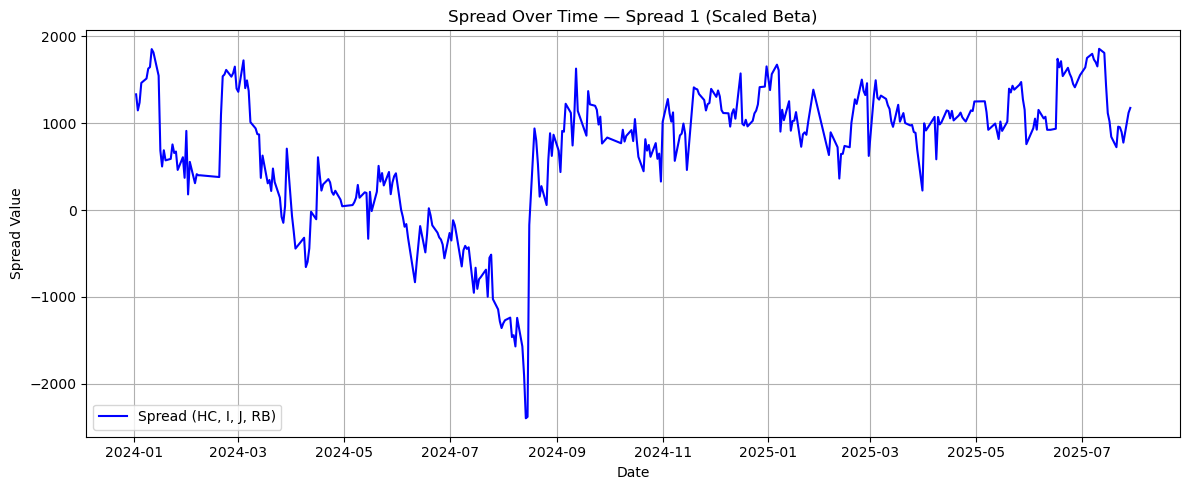

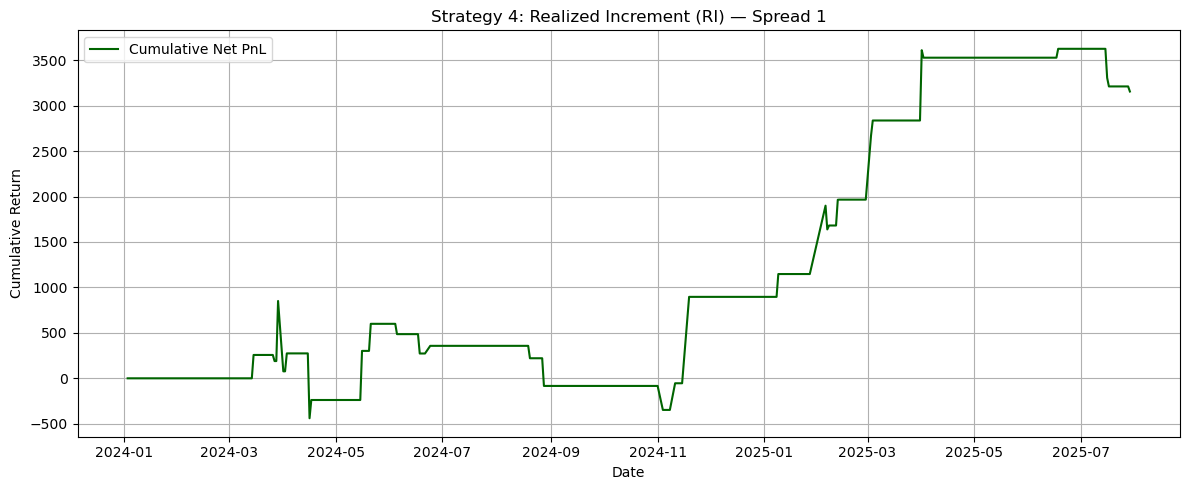

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === Step 0: Load Data ===
df = pd.read_excel("futures_clean.csv.xlsx", index_col=0, parse_dates=True)
df_coint = df[['RB', 'J', 'I', 'HC']].dropna()
df_oos = df_coint.iloc[833:]

# === Step 1: Construct Spread with Scaled Beta ===
beta_1_scaled = np.array([6.5748, -1.566, -0.6142, -5.0005])
spread = df_oos.values @ beta_1_scaled
spread = pd.Series(spread, index=df_oos.index)

# === Step 2: Compute Spread Increment ===
increment = spread.pct_change().fillna(0)

# === Step 3: Strategy Parameters ===
window = 46
alpha = 0.03
cost = 0.0005

# === Step 4: Initialize Position ===
position = np.zeros(len(spread))
q_low = np.full(len(spread), np.nan)
q_high = np.full(len(spread), np.nan)

# === Step 5: Rolling Quantiles and Position Logic ===
for i in range(window, len(spread)):
    window_increments = increment.iloc[i - window:i]
    q_alpha = np.quantile(window_increments, alpha)
    q_1_alpha = np.quantile(window_increments, 1 - alpha)
    q_low[i] = q_alpha
    q_high[i] = q_1_alpha

    # No open position
    if position[i - 1] == 0:
        if increment.iloc[i] < q_alpha:
            position[i] = 1   # Long
        elif increment.iloc[i] > q_1_alpha:
            position[i] = -1  # Short
        else:
            position[i] = 0
    else:
        # Exit if increment crosses back inside the band
        if q_alpha <= increment.iloc[i] <= q_1_alpha:
            position[i] = 0
        else:
            position[i] = position[i - 1]  # Hold

position = pd.Series(position, index=spread.index)

# === Step 6: Compute Returns ===
spread_return = spread.diff().fillna(0)
turnover = position.diff().abs()
strategy_returns = position.shift(1) * spread_return
costs = turnover * cost
net_returns = strategy_returns - costs
cumulative_pnl = net_returns.cumsum()

# === Step 7: Metrics ===
sharpe = net_returns.mean() / net_returns.std() * np.sqrt(252) if net_returns.std() > 0 else 0
max_dd = (cumulative_pnl.cummax() - cumulative_pnl).max()
win_rate = (net_returns > 0).sum() / (net_returns != 0).sum()
total_return = cumulative_pnl.iloc[-1]

# === Step 8: Print Summary ===
print("📊 Realized Increment Strategy (RI) — Out-of-Sample, Spread 1")
print(f"Rolling Window       : {window}")
print(f"Alpha Quantiles      : {alpha:.3f}, {1-alpha:.3f}")
print(f"Sharpe Ratio         : {sharpe:.4f}")
print(f"Total Return         : {total_return:.4f}")
print(f"Max Drawdown         : {max_dd:.4f}")
print(f"Win Rate             : {win_rate:.2%}")

# === Step 9: Plot Spread ===
plt.figure(figsize=(12, 5))
plt.plot(spread, label="Spread (HC, I, J, RB)", color="blue")
plt.title("Spread Over Time — Spread 1 (Scaled Beta)")
plt.xlabel("Date")
plt.ylabel("Spread Value")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# === Step 10: Plot Strategy Cumulative PnL ===
plt.figure(figsize=(12, 5))
plt.plot(cumulative_pnl, label="Cumulative Net PnL", color="darkgreen")
plt.title("Strategy 4: Realized Increment (RI) — Spread 1")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


✅ Excel saved: Realized Increment Strategy with Integer Hands.xlsx

🔍 Realized Increment Strategy (All Data, Integer Hands)
Initial Capital Deployed: 0.00 RMB
Final Cumulative Profit: 17,323,353.32 RMB
Profit Rate: inf%
Sharpe Ratio: 0.8786
Max Drawdown: 4,531,138.10
Win Rate: 32.49%


C:\Users\chris\AppData\Local\Temp\ipykernel_53396\3781882648.py:122: RuntimeWarning: divide by zero encountered in scalar divide
  profit_rate = final_profit / initial_capital


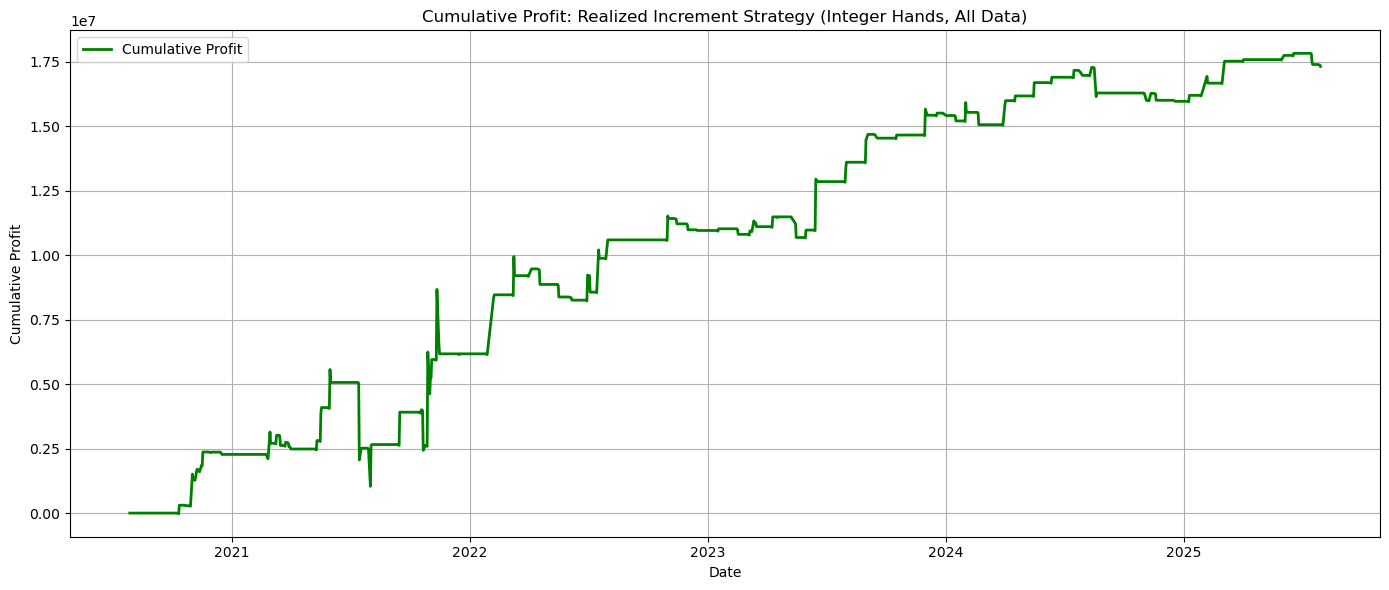

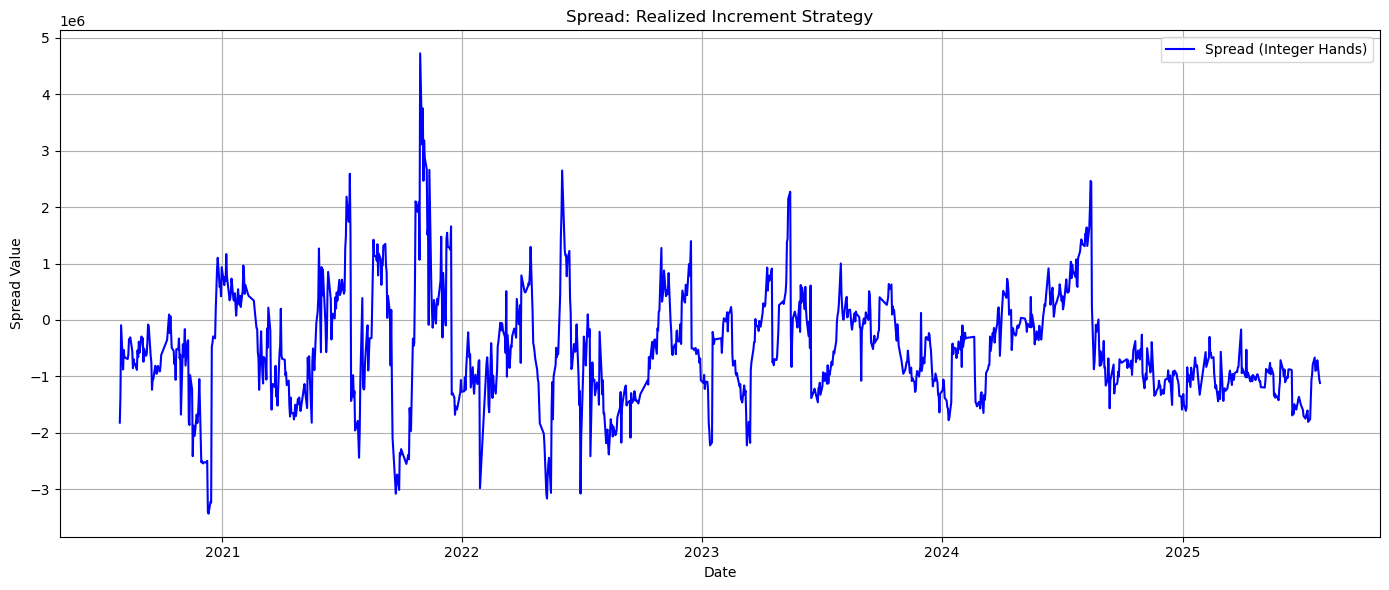

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# === Step 0: Load data ===
df = pd.read_excel("futures_clean.csv.xlsx", index_col=0, parse_dates=True)
df_coint = df[['HC', 'I', 'J', 'RB']].dropna()
df_coint_full = df_coint.copy()  # Use the full dataset

# === Step 1: Define beta and contract size info ===
original_beta = {'HC': 5.00051, 'I': 0.6142, 'J': 1.56603, 'RB': -6.57481}
contract_sizes = {'HC': 10, 'I': 100, 'J': 100, 'RB': 10}
scaling_factor = 1000
scaled_beta = {k: original_beta[k] * scaling_factor for k in original_beta}
scaled_hands = {k: round(scaled_beta[k] / contract_sizes[k]) for k in scaled_beta}

# Final scaled beta vector
beta_1 = np.array([
    scaled_hands['HC'] * contract_sizes['HC'],
    scaled_hands['I']  * contract_sizes['I'],
    scaled_hands['J']  * contract_sizes['J'],
    scaled_hands['RB'] * contract_sizes['RB']
])

# === Step 2: Compute Spread and Increment ===
spread = df_coint_full[['HC', 'I', 'J', 'RB']].values @ beta_1
spread = pd.Series(spread, index=df_coint_full.index)
increment = spread.diff().fillna(0)

# === Step 3: Realized Increment Strategy Parameters ===
window = 46
alpha = 0.03
cost = 0.0005

# === Step 4: Signal Generation ===
position = np.zeros(len(spread))
q_low = np.full(len(spread), np.nan)
q_high = np.full(len(spread), np.nan)

for i in range(window, len(spread)):
    window_increments = increment.iloc[i - window:i]
    q_alpha = np.quantile(window_increments, alpha)
    q_1_alpha = np.quantile(window_increments, 1 - alpha)
    q_low[i] = q_alpha
    q_high[i] = q_1_alpha

    if position[i - 1] == 0:
        if increment.iloc[i] < q_alpha:
            position[i] = 1
        elif increment.iloc[i] > q_1_alpha:
            position[i] = -1
        else:
            position[i] = 0
    else:
        if q_alpha <= increment.iloc[i] <= q_1_alpha:
            position[i] = 0
        else:
            position[i] = position[i - 1]

position = pd.Series(position, index=spread.index)

# === Step 5: PnL and Exposure Tracking ===
daily_profit = [0]
cumulative_profit = [0]
gross_exposure = []
net_exposure = []
position_type = []
position_details = []

# First day placeholder
position_details.append({k: 0 for k in ['HC', 'I', 'J', 'RB']})
gross_exposure.append(0)
net_exposure.append(0)
position_type.append("None")

for i in range(1, len(df_coint_full)):
    prices = df_coint_full.iloc[i]
    pos_yesterday = position.iloc[i - 1]
    pos_today = position.iloc[i]

    # Compute notional per asset
    value_dict = {}
    for k in ['HC', 'I', 'J', 'RB']:
        hands = scaled_hands[k]
        size = contract_sizes[k]
        price = prices[k]
        notional = pos_today * hands * size * price
        value_dict[k] = notional

    total_gross = sum(abs(v) for v in value_dict.values())
    total_net = abs(sum(value_dict.values()))
    spread_change = spread.iloc[i] - spread.iloc[i - 1]
    profit = spread_change * pos_yesterday

    if pos_today != pos_yesterday:
        profit -= cost * total_gross

    daily_profit.append(profit)
    cumulative_profit.append(cumulative_profit[-1] + profit)
    gross_exposure.append(total_gross)
    net_exposure.append(total_net)
    position_details.append(value_dict)
    position_type.append("Long" if pos_today == 1 else "Short" if pos_today == -1 else "None")

# === Step 6: Save Output to Excel ===
exposure_df = pd.DataFrame({
    'Position': position_type,
    'Gross Exposure': gross_exposure,
    'Net Exposure': net_exposure,
    'Daily Profit': daily_profit,
    'Cumulative Profit': cumulative_profit
}, index=df_coint_full.index)

positions_df = pd.DataFrame(position_details, index=df_coint_full.index)
output_df = pd.concat([exposure_df, positions_df], axis=1)
output_df.to_excel("Realized Increment Strategy with Integer Hands.xlsx")
print("✅ Excel saved: Realized Increment Strategy with Integer Hands.xlsx")

# === Step 7: Performance Summary ===
initial_capital = gross_exposure[1]
final_profit = cumulative_profit[-1]
profit_rate = final_profit / initial_capital
daily_returns = pd.Series(daily_profit[1:], index=df_coint_full.index[1:])
sharpe = daily_returns.mean() / daily_returns.std() * np.sqrt(252)
max_drawdown = (pd.Series(cumulative_profit, index=df_coint_full.index).cummax() - pd.Series(cumulative_profit, index=df_coint_full.index)).max()
win_rate = (daily_returns > 0).sum() / (daily_returns != 0).sum()

print("\n🔍 Realized Increment Strategy (All Data, Integer Hands)")
print(f"Initial Capital Deployed: {initial_capital:,.2f} RMB")
print(f"Final Cumulative Profit: {final_profit:,.2f} RMB")
print(f"Profit Rate: {profit_rate:.2%}")
print(f"Sharpe Ratio: {sharpe:.4f}")
print(f"Max Drawdown: {max_drawdown:,.2f}")
print(f"Win Rate: {win_rate:.2%}")

# === Step 8: Plot Cumulative Profit ===
plt.figure(figsize=(14, 6))
plt.plot(df_coint_full.index, cumulative_profit, label='Cumulative Profit', color='green', linewidth=2)
plt.title("Cumulative Profit: Realized Increment Strategy (Integer Hands, All Data)")
plt.xlabel("Date")
plt.ylabel("Cumulative Profit")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# === Step 9: Plot Spread ===
plt.figure(figsize=(14, 6))
plt.plot(spread, label='Spread (Integer Hands)', color='blue')
plt.title("Spread: Realized Increment Strategy")
plt.xlabel("Date")
plt.ylabel("Spread Value")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
